In [1]:
from xgboost import XGBRanker

from util import get_antisense

model = XGBRanker()
model.load_model('ranker_model2.json')

In [2]:
from asodesigner.read_human_genome import get_locus_to_data_dict
import pickle
from asodesigner.consts import CACHE_DIR

genes_u = ['HIF1A', 'APOL1', 'YAP1', 'SOD1', 'SNCA', 'IRF4', 'KRAS', 'KLKB1', 'SNHG14', 'DGAT2', 'IRF5', 'HTRA1',
           'MYH7', 'MALAT1', 'HSD17B13']
cache_path = CACHE_DIR / 'gene_to_data_simple_cache.pickle'
if not cache_path.exists():
    gene_to_data = get_locus_to_data_dict(include_introns=True, gene_subset=genes_u)
    with open(cache_path, 'wb') as f:
        pickle.dump(gene_to_data, f)
else:
    with open(cache_path, 'rb') as f:
        gene_to_data = pickle.load(f)

In [3]:
from scripts.data_genertion.consts import *
from scripts.features.feature_extraction import load_all_features

main_df = load_all_features()
main_df[SEQUENCE] = main_df[SEQUENCE].astype(str)

In [4]:
from scripts.data_genertion.data_handling import get_populated_df_with_structure_features

main_df = get_populated_df_with_structure_features(main_df, genes_u, gene_to_data)
main_df.loc[:, 'mrna_length'] = [len(gene_to_data[gene].full_mrna) for gene in main_df[CANONICAL_GENE]]
main_df['normalized_sense_start_from_end'] = main_df['sense_start_from_end'] / main_df['mrna_length']

In [5]:
feat_names = model.get_booster().feature_names

In [14]:
feat_names

['Treatment_Period(hours)',
 'at_skew',
 'CAI_score_global_CDS',
 'stop_codon_count',
 'sense_avg_accessibility',
 'on_target_fold_openness_normalized40_15',
 'sense_utr',
 'nucleotide_diversity',
 'internal_fold',
 'normalized_start',
 'RNaseH1_Krel_score_R7_krel',
 'hairpin_score',
 'Modification_min_distance_to_3prime',
 'at_rich_region_score']

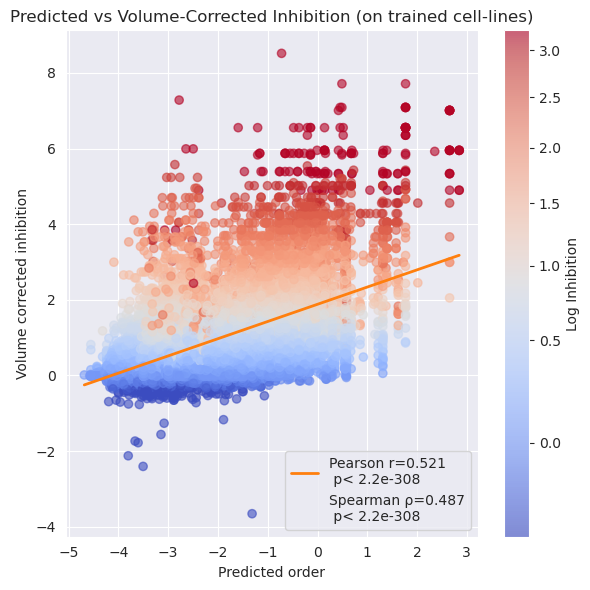

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, linregress
from matplotlib.colors import PowerNorm

first_filtered = main_df.copy()
first_filtered = first_filtered[first_filtered['Cell line organism'] == 'human']
first_filtered = first_filtered.dropna(subset=[INHIBITION]).copy()
first_filtered = first_filtered[first_filtered[CELL_LINE].isin(['A431', 'SK-MEL-28', 'MM.1R', 'KARPAS-229'])]
# first_filtered = first_filtered[first_filtered[CELL_LINE].isin(['U251'])]

log_correction = 1.01
first_filtered.loc[:, 'log_inhibition'] = -np.log(log_correction - first_filtered[INHIBITION] / 100)

predicted = model.predict(first_filtered[feat_names])

li = first_filtered['log_inhibition']
first_filtered['correct_log_inhibition2'] = li / (first_filtered[VOLUME] * 0.0000601 + 0.537)
truth = first_filtered['correct_log_inhibition2'].to_numpy()

from math import isfinite

# --- helper to format p-values (smallest positive float64, not eps) ---
TINY = np.finfo(np.float64).tiny  # ≈ 2.22e-308
def fmt_p(p):
    p = float(np.asarray(p).squeeze())
    if p <= 0.0 or p < TINY:
        return f"< {TINY:.1e}"
    return f"{p:.1e}"

# --- colors: softer reds, faster transition ---
vals = first_filtered['log_inhibition'].to_numpy()
vmin, vmax = np.percentile(vals, [1, 99])  # clip extremes
norm = PowerNorm(gamma=0.6, vmin=vmin, vmax=vmax)
cmap = 'coolwarm'  # softer than RdBu_r

plt.figure(figsize=(6,6))
sc = plt.scatter(predicted, truth, c=vals, cmap=cmap, norm=norm, alpha=0.6)

# Pearson correlation & regression line
pear_r, pear_p = pearsonr(predicted, truth)
lr = linregress(predicted, truth)
xs = np.linspace(predicted.min(), predicted.max(), 200)
ys = lr.slope * xs + lr.intercept
plt.plot(xs, ys, color="C1", lw=2,
         label=f"Pearson r={pear_r:.3f}\n p{fmt_p(pear_p)}")

# Spearman correlation (stats only, in legend)
spear_rho, spear_p = spearmanr(predicted, truth)
plt.plot([], [], ' ', label=f"Spearman ρ={spear_rho:.3f}\n p{fmt_p(spear_p)}")

plt.xlabel("Predicted order")
plt.ylabel("Volume corrected inhibition")
plt.title("Predicted vs Volume-Corrected Inhibition (on trained cell-lines)")
plt.colorbar(sc, label="Log Inhibition")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
selected_features = model.get_booster().feature_names


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, linregress
from matplotlib.colors import PowerNorm

first_filtered = main_df.copy()
first_filtered = first_filtered[first_filtered['Cell line organism'] == 'human']
first_filtered = first_filtered.dropna(subset=[INHIBITION]).copy()
first_filtered = first_filtered[first_filtered[CELL_LINE].isin(['A431', 'SK-MEL-28', 'MM.1R', 'KARPAS-229'])]
# first_filtered = first_filtered[first_filtered[CELL_LINE].isin(['U251'])]

log_correction = 1.01
first_filtered.loc[:, 'log_inhibition'] = -np.log(log_correction - first_filtered[INHIBITION] / 100)

predicted = model.predict(first_filtered[selected_features])

li = first_filtered['log_inhibition']
first_filtered['correct_log_inhibition2'] = li / (first_filtered[VOLUME] * 0.0000601 + 0.537)
truth = first_filtered['correct_log_inhibition2'].to_numpy()

from math import isfinite

# --- helper to format p-values (smallest positive float64, not eps) ---
TINY = np.finfo(np.float64).tiny  # ≈ 2.22e-308
def fmt_p(p):
    p = float(np.asarray(p).squeeze())
    if p <= 0.0 or p < TINY:
        return f"< {TINY:.1e}"
    return f"{p:.1e}"

# --- colors: softer reds, faster transition ---
vals = first_filtered['log_inhibition'].to_numpy()
vmin, vmax = np.percentile(vals, [1, 99])  # clip extremes
norm = PowerNorm(gamma=0.6, vmin=vmin, vmax=vmax)
cmap = 'coolwarm'  # softer than RdBu_r

import pandas as pd

n_points = len(predicted)
plt.figure(figsize=(6,6))

# --- main scatter ---
sc = plt.scatter(
    predicted, truth,
    c=vals, cmap=cmap, norm=norm,
    s=10, alpha=0.35, linewidths=0, rasterized=True
)

# --- binning without cutoffs ---
df_plot = pd.DataFrame({"x": predicted, "y": truth})
nbins = 40
bins = np.linspace(predicted.min(), predicted.max(), nbins + 1)
df_plot["bin"] = np.digitize(df_plot["x"], bins)

summary = df_plot.groupby("bin", observed=True).agg(
    x_mid=("x", "mean"),
    y_med=("y", "median"),
    y_p10=("y", lambda s: np.percentile(s, 10)),
    y_p90=("y", lambda s: np.percentile(s, 90)),
).dropna()

# --- ribbon and central trend ---
plt.fill_between(summary["x_mid"], summary["y_p10"], summary["y_p90"],
                 alpha=0.18, linewidth=0)
plt.plot(summary["x_mid"], summary["y_med"], lw=2, label="Binned median ±10–90%")

# --- stats only in legend ---
pear_r, pear_p = pearsonr(predicted, truth)
spear_rho, spear_p = spearmanr(predicted, truth)
plt.plot([], [], ' ', label=f"Pearson r={pear_r:.3f}, p{fmt_p(pear_p)}")
plt.plot([], [], ' ', label=f"Spearman ρ={spear_rho:.3f}, p{fmt_p(spear_p)}")
plt.plot([], [], ' ', label=f"n={n_points:,d}")

plt.xlabel("Predicted ranking (higher is better)")
plt.ylabel("Volume corrected inhibition")
plt.title("Predicted vs Volume-Corrected Inhibition (on trained cell-lines)")
plt.colorbar(sc, label="Log Inhibition")
plt.legend()
plt.tight_layout()
plt.show()


NDCG@k: {5: 0.8104, 10: 0.8084, 20: 0.8277, 50: 0.8444, 100: 0.8079}
Prec@k: {5: 1.0, 10: 0.9, 20: 0.85, 50: 0.76, 100: 0.54}


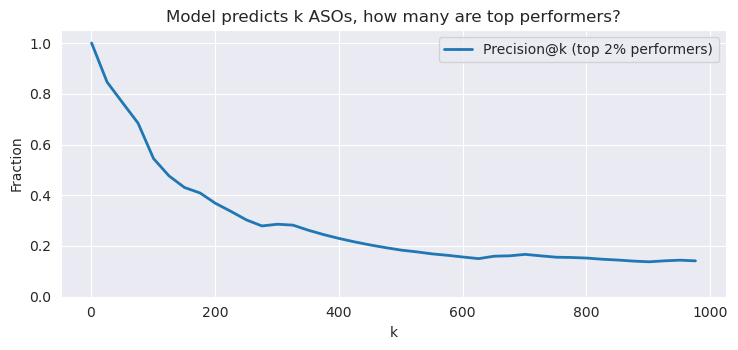

In [12]:
# ==== Ranking metrics: NDCG@k (graded) + Precision@k (binary top-10%) ====
import numpy as np
import matplotlib.pyplot as plt

y_pred = np.asarray(predicted).astype(float)
y_true = np.asarray(truth).astype(float)

# --- graded relevance in [0,1] (monotone with truth) ---
tmin, tmax = np.nanmin(y_true), np.nanmax(y_true)
den = (tmax - tmin) if (tmax > tmin) else 1.0
rel = (y_true - tmin) / den  # ∈ [0,1]

# --- ranking by predictions (desc) ---
order = np.argsort(-y_pred)
rel_ranked = rel[order]

# --- DCG / IDCG helpers ---
def dcg_at_k(g, k):
    k = int(min(k, g.size))
    if k <= 0: return 0.0
    # log2 discount; add 2 to avoid log(1)=0 at position 1
    discounts = 1.0 / np.log2(np.arange(2, k + 2))
    return float(np.sum(g[:k] * discounts))

def ndcg_at_k(g, k):
    k = int(min(k, g.size))
    if k <= 0: return 0.0
    ideal = np.sort(g)[::-1]
    idcg = dcg_at_k(ideal, k)
    return dcg_at_k(g, k) / idcg if idcg > 0 else 0.0

# --- Precision@k on binary labels: top-10% truth are "positives" ---
pos_q = 0.02
thr = np.quantile(y_true, 1.0 - pos_q)
y_bin = (y_true >= thr).astype(int)
y_bin_ranked = y_bin[order]

def precision_at_k(b, k):
    k = int(min(k, b.size))
    if k <= 0: return 0.0
    return float(np.sum(b[:k])) / k

# --- evaluate over a k-grid ---
N = y_true.size
ks = np.arange(1, min(1000, N)+1, 25)   # every 25 up to 1000

ndcgs = np.array([ndcg_at_k(rel_ranked, k) for k in ks])
precs = np.array([precision_at_k(y_bin_ranked, k) for k in ks])

# --- summary table for a few canonical k's ---
k_show = [5, 10, 20, 50, 100]
k_show = [k for k in k_show if k <= N]
ndcgs_show = [ndcg_at_k(rel_ranked, k) for k in k_show]
precs_show = [precision_at_k(y_bin_ranked, k) for k in k_show]
print("NDCG@k:", dict(zip(k_show, [round(v, 4) for v in ndcgs_show])))
print("Prec@k:", dict(zip(k_show, [round(v, 4) for v in precs_show])))

# --- plots (truncate at k=1000) ---
k_cut = 2000
mask = ks <= k_cut

plt.figure(figsize=(7.5, 3.6))
plt.plot(ks[mask], precs[mask], lw=2, label=f"Precision@k (top {int(pos_q*100)}% performers)")
plt.xlabel("k")
plt.ylabel("Fraction")
plt.title("Model predicts k ASOs, how many are top performers?")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Extract feature names and importances
feat_importances = model.feature_importances_

# Put into a DataFrame
fi = pd.DataFrame({
    "Feature": feat_names,
    "Importance": feat_importances
})

# Sort by importance (descending)
fi = fi.sort_values("Importance", ascending=False).reset_index(drop=True)

print(fi)


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(fi["Feature"], fi["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Feature Importances")
plt.tight_layout()
plt.show()


In [ ]:
model.get_booster().feature_names

In [ ]:
model.get_booster().feature_names

model.feature_importances_

In [ ]:
target_gene = 'DDX11L1'

from read_human_genome import get_locus_to_data_dict

gene_to_data = get_locus_to_data_dict(include_introns=True, gene_subset=[target_gene])

In [ ]:
SEQUENCE = 'Sequence'
SENSE_START = 'sense_start'
SENSE_START_FROM_END = 'sense_start_from_end'
SENSE_LENGTH = 'sense_length'
SENSE_TYPE = 'sense_type'
SENSE_EXON = 'sense_exon'
SENSE_INTRON = 'sense_intron'
SENSE_UTR = 'sense_utr'

In [ ]:
CELL_LINE_ORGANISM = 'Cell line organism'
INHIBITION = 'Inhibition(%)'
CANONICAL_GENE = 'Canonical Gene Name'

In [ ]:
from asodesigner.util import get_antisense
import pandas as pd


def get_init_df(target_mrna, aso_sizes=[16, 20]):
    candidates = []
    sense_starts = []
    sense_lengths = []
    sense_starts_from_end = []

    for aso_size in aso_sizes:
        for i in range(0, len(target_mrna) - (aso_size - 1)):
            target = target_mrna[i: i + aso_size]
            candidates.append(get_antisense(str(target)))
            sense_starts.append(i)
            sense_lengths.append(aso_size)
            sense_starts_from_end.append(i)
    df = pd.DataFrame({SEQUENCE: candidates, SENSE_START: sense_starts, SENSE_LENGTH: sense_lengths,
                       SENSE_START_FROM_END: sense_starts_from_end})
    return df


init_df = get_init_df(target_mrna=gene_to_data[target_gene].full_mrna, aso_sizes=[16, 20])

In [ ]:
init_df[CANONICAL_GENE] = target_gene
init_df[CELL_LINE_ORGANISM] = 'human'
init_df[INHIBITION] = 0

In [ ]:
import numpy as np


def get_populated_df_with_structure_features(df, genes_u, gene_to_data):
    """
    Populate "the data" df with features like exon/intron, start of the sense strand, if found.
    """
    df_copy = df.copy()
    all_data_human = df_copy[df_copy[CELL_LINE_ORGANISM] == 'human']
    all_data_human_no_nan = all_data_human.dropna(subset=[INHIBITION]).copy()
    all_data_human_gene = all_data_human_no_nan[all_data_human_no_nan[CANONICAL_GENE].isin(genes_u)].copy()

    found = 0
    all_data_human_gene[SENSE_START] = np.zeros_like(all_data_human_gene[CANONICAL_GENE], dtype=int)
    all_data_human_gene[SENSE_START_FROM_END] = np.zeros_like(all_data_human_gene[CANONICAL_GENE], dtype=int)
    all_data_human_gene[SENSE_LENGTH] = np.zeros_like(all_data_human_gene[CANONICAL_GENE], dtype=int)
    all_data_human_gene[SENSE_EXON] = np.zeros_like(all_data_human_gene[CANONICAL_GENE], dtype=int)
    all_data_human_gene[SENSE_INTRON] = np.zeros_like(all_data_human_gene[CANONICAL_GENE], dtype=int)
    all_data_human_gene[SENSE_UTR] = np.zeros_like(all_data_human_gene[CANONICAL_GENE], dtype=int)
    all_data_human_gene[SENSE_TYPE] = "NA"
    for index, row in all_data_human_gene.iterrows():
        gene_name = row[CANONICAL_GENE]
        locus_info = gene_to_data[gene_name]
        pre_mrna = locus_info.full_mrna
        antisense = row[SEQUENCE]
        sense = get_antisense(antisense)
        idx = pre_mrna.find(sense)
        all_data_human_gene.loc[index, SENSE_START] = idx
        all_data_human_gene.loc[index, SENSE_START_FROM_END] = np.abs(
            locus_info.exon_indices[-1][1] - locus_info.cds_start - idx)
        all_data_human_gene.loc[index, SENSE_LENGTH] = len(antisense)
        if idx != -1:
            genome_corrected_index = idx + locus_info.cds_start
            found = False
            for exon_indices in locus_info.exon_indices:
                # print(exon[0], exon[1])
                if exon_indices[0] <= genome_corrected_index <= exon_indices[1]:
                    all_data_human_gene.loc[index, SENSE_TYPE] = 'exon'
                    all_data_human_gene.loc[index, SENSE_EXON] = 1
                    found = True
                    break
            for intron_indices in locus_info.intron_indices:
                # print(exon[0], exon[1])
                if intron_indices[0] <= genome_corrected_index <= intron_indices[1]:
                    all_data_human_gene.loc[index, SENSE_TYPE] = 'intron'
                    all_data_human_gene.loc[index, SENSE_INTRON] = 1
                    found = True
                    break
            for i, utr_indices in enumerate(locus_info.utr_indices):
                if utr_indices[0] <= genome_corrected_index <= utr_indices[1]:
                    all_data_human_gene.loc[index, SENSE_TYPE] = 'utr'
                    all_data_human_gene.loc[index, SENSE_UTR] = 1

                    found = True
                    break
        if not found:
            all_data_human_gene.loc[index, SENSE_TYPE] = 'intron'
    return all_data_human_gene

In [ ]:
populated = get_populated_df_with_structure_features(init_df, [target_gene], gene_to_data)

In [ ]:
from scripts.data_genertion.data_handling import populate_features

VOLUME = 'ASO_volume(nM)'
TREATMENT_PERIOD = 'Treatment_Period(hours)'

target_mrna = gene_to_data[target_gene].full_mrna

populated[TREATMENT_PERIOD] = 24  # keep constant for all
populated[VOLUME] = 1000  # keep constant for all
populated['log_volume'] = np.log(populated[VOLUME])
populated['normalized_start'] = populated[SENSE_START] / len(target_mrna)
populated['normalized_sense_start_from_end'] = populated['sense_start_from_end'] / len(target_mrna)
easy_to_populate = ['at_skew', 'gc_content', 'gc_content_3_prime_5', 'gc_skew', 'hairpin_score',
                    'homooligo_count', 'internal_fold', 'nucleotide_diversity', 'self_energy', 'stop_codon_count',
                    'at_rich_region_score', 'poly_pyrimidine_stretch']
populate_features(populated, easy_to_populate)

In [ ]:
import math
import ViennaRNA as RNA


def get_weighted_energy(target_start, l, step_size, energies, window_size):
    """
    Calculate average energy for a target region by finding which sliding windows
    overlap each position and averaging their energies.
    """
    if l <= 0 or len(energies) == 0:
        return 0.0

    num_windows = len(energies)
    position_energies = np.zeros(l, dtype=np.float64)

    for position in range(target_start, target_start + l):
        # Find all windows that overlap this position
        # A window at index k covers positions from k*step_size to k*step_size + window_size - 1

        # First window that could overlap: its end must reach this position
        first_window = max(0, math.ceil((position - window_size + 1) / step_size))

        # Last window that could overlap: its start must be at or before this position
        last_window = min(num_windows - 1, position // step_size)

        if first_window > last_window:
            # No windows fully overlap - use the closest window
            closest_window = np.clip(position // step_size, 0, num_windows - 1)
            energy_value = float(energies[closest_window])
        else:
            # Average all overlapping windows
            energy_value = float(np.mean(energies[first_window:last_window + 1], dtype=np.float64))

        position_energies[position - target_start] = energy_value

    return float(np.mean(position_energies, dtype=np.float64))


def calculate_energies(target_seq, step_size, window_size):
    L = len(target_seq)
    if L < window_size: return np.empty(0, dtype=np.float64)

    starts = list(range(0, L - window_size + 1, step_size))
    last_needed = L - window_size
    if starts[-1] != last_needed:
        starts.append(last_needed)  # add [L-window_size, L-1] window

    energies = np.empty(len(starts), dtype=np.float64)
    for k, i in enumerate(starts):
        _, mfe = RNA.fold(target_seq[i:i + window_size])
        energies[k] = float(mfe)
    return energies

In [ ]:
def get_populate_fold(df, gene_to_data, fold_variants=[(40, 15)]):
    """Calculate RNA folding energies for each sequence in the dataframe."""
    from asodesigner.fold import calculate_energies, get_weighted_energy

    result_df = df.copy()

    for window_size, step_size in fold_variants:
        # Create column names for this window configuration
        fold_col = f'on_target_fold_openness{window_size}_{step_size}'
        norm_col = f'on_target_fold_openness_normalized{window_size}_{step_size}'

        # Initialize columns
        num_rows = len(result_df)
        result_df[fold_col] = np.zeros(num_rows, dtype=np.float64)
        result_df[norm_col] = np.zeros(num_rows, dtype=np.float64)

        # Cache energies for each gene to avoid recalculation
        gene_energies_cache = {}

        # Calculate weighted energy for each sequence region
        for idx, row in result_df.iterrows():
            target_gene = row[CANONICAL_GENE]

            # Calculate energies for this gene if not cached
            if target_gene not in gene_energies_cache:
                target_sequence = gene_to_data[target_gene].full_mrna
                gene_energies_cache[target_gene] = calculate_energies(
                    str(target_sequence), step_size, window_size
                )

            energies = gene_energies_cache[target_gene]

            length = row[SENSE_LENGTH]
            start_pos = row[SENSE_START]

            # Get average energy for this region
            avg_energy = get_weighted_energy(start_pos, length, step_size, energies, window_size)

            # Store raw and normalized values
            result_df.loc[idx, fold_col] = avg_energy
            result_df.loc[idx, norm_col] = avg_energy / length

    return result_df

In [ ]:
fold_variants = [(40, 15)]
populated = get_populate_fold(populated, gene_to_data, fold_variants=fold_variants)

In [ ]:
features = model.get_booster().feature_names
populated[features]

In [ ]:
# Assign modifications
from asodesigner.features.mod_features import compute_mod_min_distance_to_3prime

MODIFICATION = 'Modification'


class Modification:
    LNA_GAPMER = 'lna_gapmer'
    MOE_GAPMER = 'moe_gapmer'
    CUSTOM = 'custom'


def mk(length, mod, gap_len):
    length = int(length)
    core = length - 2 * gap_len
    if core < 0:
        raise ValueError(f"length {length} too short for flank {gap_len}")
    return mod * gap_len + 'd' * core + mod * gap_len


def flank_for_len(n: int):
    n = int(n)
    if n == 20:  # MOE_GAPMER
        return 'M', 5
    if n == 16:  # LNA_GAPMER
        return 'L', 3
    raise ValueError(f"Unsupported length {n}; only 16/20 are handled.")


populated[MODIFICATION] = populated['sense_length'].apply(lambda n: mk(n, *flank_for_len(n)))
populated[MODIFICATION] = populated[MODIFICATION].astype("string")